# TP 3  : Graph Neural Networks Architecture

**Tom Welch, Quentin Moyadpouer, Harshit Morj**

# TUTORIAL

### Install Pytorch Geometric

To handle graph data, we use the library Pytorch Geometric : https://pytorch-geometric.readthedocs.io/en/latest/

*   If you use _Google Colab_, simply run the following cell to install Pytorch Geometric (**advised**).
*   If you plan using your _own environment_, follow the documentation to install Pytorch Geometric : https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html and skip the following cell.

In [1]:
########## INSTALL TORCH GEOMETRIC ##################
# https://pytorch-geometric.readthedocs.io/en/latest/
#####################################################
import torch


def format_pytorch_version(version):
    return version.split("+")[0]


TORCH_version = torch.__version__
TORCH = format_pytorch_version(TORCH_version)


def format_cuda_version(version):
    return "cu" + version.replace(".", "")


CUDA_version = torch.version.cuda
CUDA = format_cuda_version(CUDA_version)

!pip install torch-scatter     -f https://pytorch-geometric.com/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-sparse      -f https://pytorch-geometric.com/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-cluster     -f https://pytorch-geometric.com/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-spline-conv -f https://pytorch-geometric.com/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-geometric


Looking in links: https://pytorch-geometric.com/whl/torch-2.6.0+cu118.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.6.0+cu118.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.6.0+cu118.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.6.0+cu118.html


### Import required packages

Run the following cell to import all required packages. This cell **must not** be modified.

To significantly accelerate your training, it is advised to use GPU. Using Google Colab, you need to activate it : 

*   Edit --> Notebook Setting --> Hardware accelerator --> GPU

In [2]:
#####################################################
################## PACKAGES #########################
#####################################################
import numpy as np
import matplotlib.pyplot as plt
import torch

import torch.nn as nn
import torch_geometric.nn as graphnn
from sklearn.metrics import f1_score
from torch_geometric.datasets import PPI
from torch_geometric.loader import DataLoader

### Dataset

We use the Protein-Protein Interaction (PPI) network dataset which includes:
- 20 graphs for training 
- 2 graphs for validation
- 2 graphs for testing

One graph of the PPI dataset has on average 2372 nodes. Each node has:
- 50 features : positional gene sets / motif gene / immunological signatures ...
- 121 (binary) labels : gene ontology sets (way to classify gene products like proteins).

**This problem aims to predict, for a given PPI graph, the correct nodes' labels**.

**It is a node (multi-label) classification task** (trained using supervised learning, with labels to be predicted for each node). 

For your curiosity, more detailed information on the dataset and some applications:
- https://cs.stanford.edu/~jure/pubs/pathways-psb18.pdf
- https://arxiv.org/abs/1707.04638

To understand how a graph data is implemented in Pytorch Geometric, refer to : https://pytorch-geometric.readthedocs.io/en/latest/get_started/introduction.html


In [3]:
### LOAD DATASETS

BATCH_SIZE = 2

# Train Dataset
train_dataset = PPI(root="", split="train")
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
# Val Dataset
val_dataset = PPI(root="", split="val")
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
# Test Dataset
test_dataset = PPI(root="", split="test")
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Number of features and classes
n_features, n_classes = train_dataset[0].x.shape[1], train_dataset[0].y.shape[1]

print("Number of samples in the train dataset: ", len(train_dataset))
print("Number of samples in the val dataset: ", len(test_dataset))
print("Number of samples in the test dataset: ", len(test_dataset))
print("Output of one sample from the train dataset: ", train_dataset[0])
print("Edge_index :")
print(train_dataset[0].edge_index)
print("Number of features per node: ", n_features)
print("Number of classes per node: ", n_classes)

Number of samples in the train dataset:  20
Number of samples in the val dataset:  2
Number of samples in the test dataset:  2
Output of one sample from the train dataset:  Data(x=[1767, 50], edge_index=[2, 32318], y=[1767, 121])
Edge_index :
tensor([[   0,    0,    0,  ..., 1744, 1745, 1749],
        [ 372, 1101,  766,  ..., 1745, 1744, 1739]])
Number of features per node:  50
Number of classes per node:  121


In [4]:
next(iter(train_dataloader))

DataBatch(x=[3144, 50], edge_index=[2, 62022], y=[3144, 121], batch=[3144], ptr=[3])

### Define a basic Model

Here we define a very simple Graph Neural Network model which will be used as our baseline. This model consists of three graph convolutional layers (from https://arxiv.org/pdf/1609.02907.pdf). The first two layers computes 256 features, followed by an ELU activation function. The last layer is used for (multi-label) classification task, computing 121 features (for each node).

In [5]:
#####################################################
################## MODEL ############################
#####################################################
class BasicGraphModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.graphconv1 = graphnn.GCNConv(input_size, hidden_size)
        self.graphconv2 = graphnn.GCNConv(hidden_size, hidden_size)
        self.graphconv3 = graphnn.GCNConv(hidden_size, output_size)

        self.elu = nn.ELU()

    def forward(self, x, edge_index):
        x = self.graphconv1(x, edge_index)
        x = self.elu(x)
        x = self.graphconv2(x, edge_index)
        x = self.elu(x)
        x = self.graphconv3(x, edge_index)

        return x

Next function is designed to evaluate the performance of the model, computing the F1-Score

In [6]:
#####################################################
############### TEST FUNCTION #######################
#####################################################
def evaluate(model, loss_fcn, device, dataloader):
    score_list_batch = []

    model.eval()
    for i, batch in enumerate(dataloader):
        batch = batch.to(device)
        output = model(batch.x, batch.edge_index)
        loss_test = loss_fcn(output, batch.y)
        predict = np.where(output.detach().cpu().numpy() >= 0, 1, 0)
        score = f1_score(batch.y.cpu().numpy(), predict, average="micro")
        score_list_batch.append(score)

    return np.array(score_list_batch).mean()

Next we construct the function to train the model.

In [7]:
#####################################################
############## TRAIN FUNCTION #######################
#####################################################

from tqdm import trange

# Note: i changed a bit this function, i replaced with a tqdm bar (i love tqdm) and a parameter
# iter_log, maybe #TODO: update the tqdm bar with the loss

def train(model, loss_fcn, device, optimizer, max_epochs, train_dataloader, val_dataloader,
          iter_log=20):
    epoch_list = []
    scores_list = []

    # loop over epochs
    for epoch in trange(max_epochs):
        model.train()
        losses = []
        # loop over batches
        for i, train_batch in enumerate(train_dataloader):
            optimizer.zero_grad()
            train_batch_device = train_batch.to(device)
            # logits is the output of the model
            logits = model(train_batch_device.x, train_batch_device.edge_index)
            # compute the loss
            loss = loss_fcn(logits, train_batch_device.y)
            # optimizer step
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        loss_data = np.array(losses).mean()
        #print("Epoch {:05d} | Loss: {:.4f}".format(epoch + 1, loss_data))

        if epoch % iter_log == 0:
            # evaluate the model on the validation set
            # computes the f1-score (see next function)
            score = evaluate(model, loss_fcn, device, val_dataloader)
            print("F1-Score: {:.4f}".format(score))
            scores_list.append(score)
            epoch_list.append(epoch)

    return epoch_list, scores_list

Let's train this model !

In [8]:
### DEVICE GPU OR CPU : will select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDevice: ", device)

### Max number of epochs
max_epochs = 200

### DEFINE THE MODEL
basic_model = BasicGraphModel(input_size=n_features, hidden_size=256, output_size=n_classes).to(
    device
)

### DEFINE LOSS FUNCTION
loss_fcn = nn.BCEWithLogitsLoss()

### DEFINE OPTIMIZER
optimizer = torch.optim.Adam(basic_model.parameters(), lr=0.005)

### TRAIN THE MODEL
epoch_list, basic_model_scores = train(
    basic_model,
    loss_fcn,
    device,
    optimizer,
    max_epochs,
    train_dataloader,
    val_dataloader,
)


Device:  cuda


  0%|          | 1/200 [00:00<01:53,  1.75it/s]

F1-Score: 0.4568


  1%|          | 2/200 [00:00<01:19,  2.50it/s]

 10%|█         | 21/200 [00:07<01:05,  2.72it/s]

...

 80%|████████  | 161/200 [00:56<00:15,  2.55it/s]

F1-Score: 0.6337


 90%|█████████ | 181/200 [01:03<00:07,  2.53it/s]

F1-Score: 0.6570


100%|██████████| 200/200 [01:10<00:00,  2.85it/s]


Let's evaluate the performance of this basic model

Basic Model : F1-Score on the validation set: 0.6315


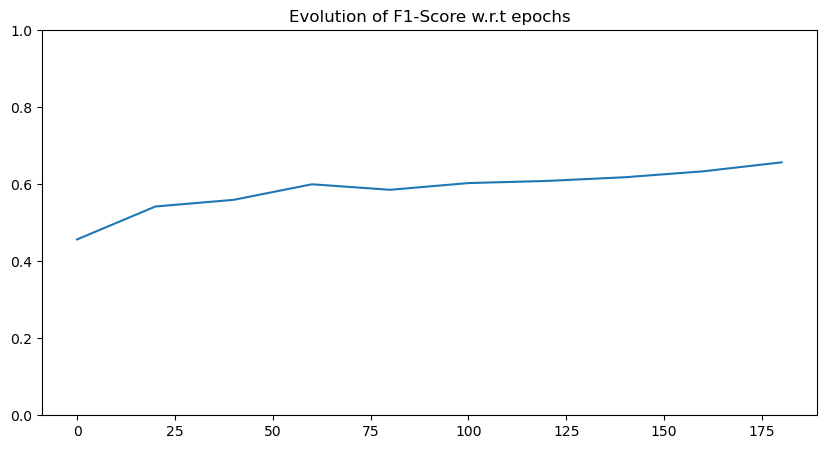

In [9]:
### F1-SCORE ON VALID DATASET
score_valid = evaluate(basic_model, loss_fcn, device, val_dataloader)
print("Basic Model : F1-Score on the validation set: {:.4f}".format(score_valid))


### PLOT EVOLUTION OF F1-SCORE W.R.T EPOCHS
def plot_f1_score(epoch_list, scores):
    plt.figure(figsize=[10, 5])
    plt.plot(epoch_list, scores)
    plt.title("Evolution of F1-Score w.r.t epochs")
    plt.ylim([0.0, 1.0])
    plt.show()


plot_f1_score(epoch_list, basic_model_scores)

# QUESTIONS

## Grading

You will be graded on 5 questions. You will need to provide at least 4 files : 
1. This Notebook
2. `class_model_gnn.py`
3. `model.pth` (the file **must be of size less than 50Mo** but 20Mo should be enough to get a very good model)
4. `conv_as_message_passing.py`

If the function you defined passes all the tests, you will get the full grade. Otherwise we  will look at the intermediate questions in the notebook to give you partial credit.



 Please provide clear, short and __bold font__ answers.  

> Question 1 : Design, build and train a model with a F1-score higher than 93% on validation set (**HINT :** https://arxiv.org/pdf/1710.10903.pdf).


In [10]:
256//2

128

In [11]:
class GraphAttention(nn.Module):
    def __init__(self, i_size=50, h_size=256//2, o_size=121, n_heads=4):
        '''
        From the articles provided, we use the "GATConv" instead of the GCN Conv
        We add some linear layers (fc_1, fc_2, o_2) to "add" information to the model
        If we remove them and keep only the GATConv, we get better results than the basic model
        but we do not atteign 93% (note: maybe we can atteign it with some hyperparameters tuning
        but by just adding those linear layers, we get good results)
        PS: on 100 epochs, with the model only with the gatconv, we get 80% f1 score with 4 heads and
        h_size=128
        '''
        super().__init__()
        # graph 
        self.attn_1 = graphnn.GATConv(i_size, h_size, heads = n_heads)
        self.attn_2 = graphnn.GATConv(n_heads*h_size, h_size, heads = n_heads)
        self.o_1 = graphnn.GATConv(n_heads*h_size, o_size, heads = n_heads, concat=False)
        # o stands for "out"

        self.fc_1 = nn.Linear(i_size, n_heads*h_size) # fc stands for function
        # but usually i denote the linear layers with fc...
        self.fc_2 = nn.Linear(n_heads*h_size, n_heads*h_size)
        self.o_2 = nn.Linear(n_heads*h_size, o_size)

        self.relu = nn.LeakyReLU() # Activation function, in practice (in our case!!!) doesn't really
        # change if we select leakyrelu, elu etc...
        
    def forward(self, x, edge_index):
        x = self.attn_1(x, edge_index) + self.fc_1(x) # the idea here is to add a residual connection
        # but x is not the same shape as attn_1(x) so we use a linear layer to have the same shape
        x = self.relu(x)
        x = self.attn_2(x, edge_index) + self.fc_2(x)
        x = self.relu(x)
        x = self.o_1(x, edge_index) + self.o_2(x)

        return x



### DEVICE GPU OR CPU : will select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # we can delete this line..
print("\nDevice: ", device)

### Max number of epochs
max_epochs = 100 # 100 should be enough

### DEFINE THE MODEL
attn_model = GraphAttention(n_features, 256//2, n_classes, n_heads=4).to(
    device
)

### DEFINE LOSS FUNCTION
loss_fcn = nn.BCEWithLogitsLoss()

### DEFINE OPTIMIZER
optimizer = torch.optim.Adam(attn_model.parameters(), lr=0.005)

### TRAIN THE MODEL
epoch_list, basic_model_scores = train(
    attn_model,
    loss_fcn,
    device,
    optimizer,
    max_epochs,
    train_dataloader,
    val_dataloader,
)



Device:  cuda


  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:01<02:29,  1.51s/it]

F1-Score: 0.4001


 21%|██        | 21/100 [00:28<01:49,  1.38s/it]

...

 61%|██████    | 61/100 [01:22<00:55,  1.43s/it]

F1-Score: 0.9213


 81%|████████  | 81/100 [01:49<00:26,  1.40s/it]

F1-Score: 0.9475


100%|██████████| 100/100 [02:15<00:00,  1.36s/it]


Basic Model : F1-Score on the validation set: 0.9550


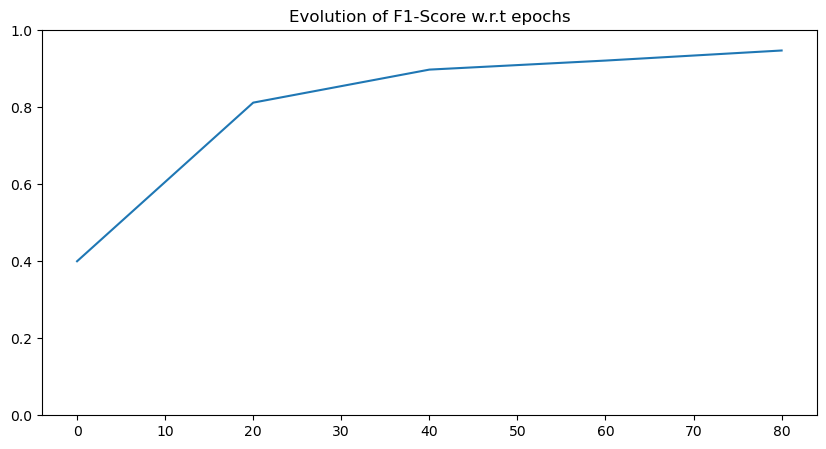

In [12]:
### F1-SCORE ON VALID DATASET
score_valid = evaluate(attn_model, loss_fcn, device, val_dataloader)
print("Basic Model : F1-Score on the validation set: {:.4f}".format(score_valid))

plot_f1_score(epoch_list, basic_model_scores)

 Provide two files : (https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 -  a file  `class_model_gnn.py` containing the class inheriting from `torch.nn.Module` architecture of your final model to load
 -  a `model.pth` file : the model weights
 
 We will  test your model on final F1-Score on a test set. You must not use the test set for hyperparameter training.
 
Intermediate question : 

 Provide the script for training, and a plot of the training loss.  

In [13]:
from class_model_gnn import StudentModel


# # Initialize model
# model = StudentModel()

# ## Save the model
# torch.save(model.state_dict(), "model.pth")


### This is the part we will run in the inference to grade your model
## Load the model
model = StudentModel()  # !  Important : No argument
model.load_state_dict(torch.load("model.pth", weights_only=True))
model.eval()
print("Model loaded successfully")

Model loaded successfully


## Conv 2D as Message Passing Neural Network


## Introduction

The use of graph is a way to structure data by adding neighborhood information between features. This then allows to do operations on the data that are local to each node and its neighbors. This is the main idea behind Graph Neural Networks (GNNs). [`pytorch-geometric`](https://pytorch-geometric.readthedocs.io/en/latest/) is a library compatible with PyTorch that allows to easily implement GNNs. The most general structure is the [`MessagePassing`](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.MessagePassing.html#torch_geometric.nn.conv.MessagePassing) class that is then used as a base for more specific GNNs as seen in the course ([Graph Convolutional Networks](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GCNConv.html#torch_geometric.nn.conv.GCNConv) or [Graph AttenTion Convolution](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GATConv.html#torch_geometric.nn.conv.GATConv)).

On the other hand, you already know an operation that uses the structure of the data to do local operations: the convolution (https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). One can see the convolution as a specific case of the message passing neural network. The goal of this notebook is to show how to use the `MessagePassing` class to implement a convolutional neural network.
You will be asked to implement 3 functions. You should give back those three functions in a file named `conv_as_message_passing.py`. These functions will then be automatically tested. So be sure to respect the function signature and the function name.


## Assumptions

To make the implementation easier we will make some assumptions:
- the input is a single image (batch size of 1) of size 'C x H x W'
- the convolution will be a 3x3 kernel with stride 1 and padding 1.

You may also assume that the Conv2D layer has no bias but it will be slightly penalized in the grading.

Bonus points will be given if you can handle the cases that are not covered by those assumptions.


## Questions

### Question 2

> Using the formalism used in the [`MessagePassing`](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.MessagePassing.html#torch_geometric.nn.conv.MessagePassing) documentation (and on [wikipedia](https://en.wikipedia.org/wiki/Graph_neural_network#Message_passing_layers) with sligthly different notations), explain how theorically you can simulate a 2D convolution using the `MessagePassing` formalism. This may include a pre-processing step to transform the image into a graph and then a post-processing step to transform the graph back into an image. (:warning: Those steps should be independent of the parameters of the convolution, but not necessarily from the hyper-parameters.)
$$\mathbf{x}_{i}^{\prime} = \gamma_{\mathbf{\Theta}}\left( \mathbf{x}_{i},\bigoplus\limits_{j \in \mathcal{N}(i)}\,\phi_{\mathbf{\Theta}}\left( \mathbf{x}_{i},\mathbf{x}_{j},\mathbf{e}_{j,i} \right) \right),$$


HINT : It is possible to do it with the following $\gamma$ : 

$$ \gamma_\Theta : x,y \mapsto y $$


**Answer:** We can simulate a 2D convolution using the MessagePassing formalism by converting the image into a graph. Each pixel becomes a node connected to its neighbors within the 3×3 convolution window. Each edge carries an attribute indicating the neighbor's relative position (which corresponds to a specific convolution filter weight). The message function $\phi$ multiplies each neighbor node's feature by the appropriate weight (based on the edge attribute), and we use sum aggregation $\bigoplus$ to accumulate these contributions at the target node. The update function $\gamma$ then simply outputs this summed value (which is the convolution result for that pixel). In practice, we perform a pre-processing step to build the graph (using the convolution's kernel size and stride for connectivity, but not the weight values) and a post-processing step to reshape the graph output back into an image.

In [14]:
import torch
import torch_geometric

### Question 3

> Implement the pre-processing function, you can use the follwing code skeleton (you may change the output type, it is just a strong suggestion):

In [15]:
def image_to_graph(
    image: torch.Tensor, conv2d: torch.nn.Conv2d | None = None
) -> torch_geometric.data.Data:
    """
    Converts an image tensor to a PyTorch Geometric Data object.
    
    Arguments:
    ----------
    image : torch.Tensor
        Image tensor of shape (C, H, W).
    conv2d : torch.nn.Conv2d, optional
        Conv2d layer to simulate, by default None
        Is used to determine the size of the receptive field.

    Returns:
    --------
    torch_geometric.data.Data
        Graph representation of the image.
    """
    # Assumptions (for a 3x3 kernel with padding=1, stride=1)
    assert image.dim() == 3, f"Expected 3D tensor, got {image.dim()}D tensor."
    if conv2d is not None:
        assert conv2d.padding[0] == conv2d.padding[1] == 1, "Expected padding of 1 on both sides."
        assert conv2d.kernel_size[0] == conv2d.kernel_size[1] == 3, "Expected kernel size of 3x3."
        assert conv2d.stride[0] == conv2d.stride[1] == 1, "Expected stride of 1."

    C, H, W = image.shape
    # Node features: flatten image pixels (each node gets the C-dimensional feature vector of a pixel)
    x = image.permute(1, 2, 0).reshape(H * W, C)

    # Construct edges and edge attributes for a 3x3 neighborhood around each pixel
    source_indices = []
    target_indices = []
    edge_attrs = []
    neighbor_offsets = [(-1, -1), (-1, 0), (-1, 1),
                        (0, -1),  (0, 0),  (0, 1),
                        (1, -1),  (1, 0),  (1, 1)]
    offset_to_index = {offset: idx for idx, offset in enumerate(neighbor_offsets)}
    for i in range(H * W):
        r = i // W
        c = i % W
        for (dr, dc) in neighbor_offsets:
            nr, nc = r + dr, c + dc
            if 0 <= nr < H and 0 <= nc < W:
                j = nr * W + nc
                source_indices.append(j)
                target_indices.append(i)
                edge_attrs.append(offset_to_index[(dr, dc)])
            # If neighbor is outside bounds, skip (zero-padding effect)

    edge_index = torch.tensor([source_indices, target_indices], dtype=torch.long)
    edge_attr = torch.tensor(edge_attrs, dtype=torch.long)
    data = torch_geometric.data.Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    return data


### Question 4

> Implement the post-processing function, you can use the follwing code skeleton:

In [16]:
def graph_to_image(
    data: torch.Tensor, height: int, width: int, conv2d: torch.nn.Conv2d | None = None
) -> torch.Tensor:
    """
    Converts a graph representation of an image to an image tensor.

    Arguments:
    ----------
    data : torch.Tensor
        Graph data representation of the image.
    height : int
        Height of the image.
    width : int
        Width of the image.
    conv2d : torch.nn.Conv2d, optional
        Conv2d layer to simulate, by default None

    Returns:
    --------
    torch.Tensor
        Image tensor of shape (C, H, W).
    """
    # Assumptions (for a 3x3 kernel with padding=1, stride=1)
    assert data.dim() == 2, f"Expected 2D tensor, got {data.dim()}D tensor."
    if conv2d is not None:
        assert conv2d.padding[0] == conv2d.padding[1] == 1, "Expected padding of 1 on both sides."
        assert conv2d.kernel_size[0] == conv2d.kernel_size[1] == 3, "Expected kernel size of 3x3."
        assert conv2d.stride[0] == conv2d.stride[1] == 1, "Expected stride of 1."

    N, C = data.shape
    assert N == height * width, "Mismatch between number of nodes and image dimensions."
    image = data.view(height, width, C).permute(2, 0, 1).contiguous()
    return image


#### Recommended test cases

We **encourage** you to test that you have the property that the pre-processing function followed by the post-processing function is the identity function.

In [17]:
ref_conv = torch.nn.Conv2d(5, 7, kernel_size=3, padding=1, stride=1)
image = torch.randn(5, 10, 11)
g_image = image_to_graph(image, ref_conv)
reconstructed_image = graph_to_image(g_image.x, 10, 11, ref_conv)
assert torch.allclose(image, reconstructed_image)

### Question 5

> Implement the `Conv2dMessagePassing` class that will simulate a 2D convolution using the `MessagePassing` formalism. 
You should inherit from the `MessagePassing` class and only change the `__init__` and `message` functions (the `forward` function has already been changed for you). You should use the following code skeleton:

In [18]:
class Conv2dMessagePassing(torch_geometric.nn.MessagePassing):
    """
    A Message Passing layer that simulates a given Conv2d layer.
    """
    def __init__(self, conv2d: torch.nn.Conv2d):
        # Initialize with sum aggregation
        super(Conv2dMessagePassing, self).__init__(aggr='add')
        self.in_channels = conv2d.in_channels
        self.out_channels = conv2d.out_channels
        # Prepare conv weights for message passing (reshape by offsets)
        weight = conv2d.weight.data.clone()
        k_h, k_w = conv2d.kernel_size
        weight = weight.reshape(self.out_channels, self.in_channels, k_h * k_w)
        weight = weight.permute(2, 0, 1).contiguous()
        self.register_buffer('weight_by_offset', weight)
        if conv2d.bias is not None:
            self.register_buffer('bias', conv2d.bias.data.clone().view(1, -1))
        else:
            self.bias = None

    def forward(self, data):
        self.edge_index = data.edge_index
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        if self.bias is not None:
            out = out + self.bias
        return out

    def message(self, x_j: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
        """
        Computes the message to be passed for each edge.
        For each edge e = (u, v) in the graph (source u to target v),
        the message through the edge e is calculated as the convolution weight corresponding to that edge's relative position times the source node's features.
        (The message is φ(u, v, e) in the formalism.)
        
        Arguments:
        ----------
        x_j : torch.Tensor
            The features of the source node for each edge (shape: E x in_channels).
        edge_attr : torch.Tensor
            The attributes of the edge (shape: E, each an offset index).
        
        Returns:
        --------
        torch.Tensor
            The message for each edge (shape: E x out_channels).
        """
        w = self.weight_by_offset[edge_attr]
        message = (w * x_j.unsqueeze(1)).sum(dim=2)
        return message


## Test example

In [19]:
from conv_as_message_passing import image_to_graph, graph_to_image, Conv2dMessagePassing

c = 5
h = 10
w = 11

ref_conv = torch.nn.Conv2d(c, 2, kernel_size=3, padding=1, stride=1, bias=False)
image = torch.randn(c, h, w)
g_image = image_to_graph(image, ref_conv)
ref_conv.weight.data = torch.randn_like(ref_conv.weight.data)

conv_mp = Conv2dMessagePassing(ref_conv)
g_image = conv_mp(g_image)

y_th = ref_conv(image)

ref_conv.weight.data = torch.randn_like(ref_conv.weight.data)
reconstructed_image = graph_to_image(g_image, h, w, ref_conv)

assert torch.allclose(y_th, reconstructed_image, atol=1e-4)
